# ⚾ LG Aimers 해커톤: 투수 제구 성공 확률 예측 EDA 및 검증 (담당 3·4 변수군)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seokjin-wq/Aimers-9th/blob/main/notebooks/LG_Aimers_EDA_roles_3_4.ipynb)

---

## 📌 1. 프로젝트 및 분석 개요

본 주피터 노트북은 **LG Aimers 해커톤: 투구 궤적 및 경기 상황 기반 투수 제구 성공 확률 예측 대회**를 위한 심층 탐색적 데이터 분석(EDA) 및 검증(Validation) 노트북입니다.

### 🎯 핵심 목표
- **예측 대상 (`control_success`)**:
  각 투구 시점에서 투수가 의도한 위치 또는 허용 범위 내로 공을 던졌으면 `1`, 그렇지 않으면 `0`인 이진 분류 타깃에 대해 **제구 성공 확률($P(\text{control\_success}=1)$)**을 정밀하게 추정합니다.
- **분석 변수 그룹**:
  1. **담당 4 변수 (투수 과거 누적 이력 및 구종 통계)**: `asof_pitcher_n`, `asof_pitcher_success_rate`, `asof_pitcher_reverse_rate`, `asof_pitcher_middle_rate`, `asof_pitcher_ball_rate`, `asof_pitcher_strike_rate`, `asof_pitcher_pitchmix_n`, `asof_pitcher_fastball_rate`, `asof_pitcher_breaking_rate`, `asof_pitcher_offspeed_rate`
  2. **담당 3 변수 (주자 상황 및 경기 중요도)**: `runner_on_1b`, `runner_on_2b`, `runner_on_3b`, `num_runners_on`, `base_state`, `home_win_expectancy`, `away_win_expectancy`, `li`
  3. **보조 변수**: `control_success`(타깃), `season`, `pitcher_id`, `top_bottom`, `inning` 등

### 🛡️ 엄격한 데이터 누수(Data Leakage) 방지 원칙
1. **평가 데이터(`test.csv`) 독립성**: `test.csv` 내부의 다른 행을 참조한 전체 집계, 빈도, rolling, expanding, target encoding을 일체 금지합니다.
2. **사전 지표(`asof_*`) 준수**: 모든 누적 이력 변수는 현재 투구 직전까지의 과거 정보로만 구성되어 있음을 확인합니다.
3. **검증 모수 격리**: 베이지안 스무딩 모수 및 Prior 확률은 반드시 각 Time-Series Fold의 **학습 데이터(Train Sub-dataset)**에서만 산출하여 검증 데이터의 타깃이 학습에 누수되지 않도록 설계합니다.


## 🛠️ 2. 환경 설정 및 유틸리티 함수 정의

- Colab 및 로컬 환경 자동 감지 및 지원
- 데이터셋 경로 후보군 자동 탐색 (환경 변수 `DATA_DIR`, 상대경로, Drive 마운트 경로 지원)
- 한글 폰트 Fallback 지원 (Windows `Malgun Gothic`, Linux/Colab `NanumGothic`, Fallback `sans-serif`)
- 메모리 절약형 데이터 로드 및 GC 관리


In [1]:
import os
import sys
import gc
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import lightgbm as lgb

# 경고 무시 및 기본 시드 고정
warnings.filterwarnings('ignore')
np.random.seed(42)

# 한글 폰트 설정 (Colab / Windows / Linux 호환 fallback)
import matplotlib.font_manager as fm

def setup_korean_font():
    font_candidates = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'AppleGothic', 'sans-serif']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    chosen_font = 'sans-serif'
    for f in font_candidates:
        if f in available_fonts or f == 'sans-serif':
            chosen_font = f
            break
    plt.rcParams['font.family'] = chosen_font
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ Matplotlib Korean font configured: {chosen_font}")

setup_korean_font()

# 표 및 시각화 스타일 설정
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# figures 및 reports 폴더 생성 (상대경로)
os.makedirs("figures", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../reports", exist_ok=True)


✅ Matplotlib Korean font configured: Malgun Gothic


## 📂 3. 효율적인 대용량 데이터 로드

약 147만 건의 `train.csv`를 메모리 효율적으로 로드하기 위해:
1. `usecols`를 지정하여 EDA 및 검증에 필수적인 23개 컬럼만 선택 로드
2. `category`, `int8`, `int16`, `float32` 등 최적의 `dtype`을 사전 매핑
3. 로컬 상대 경로 및 Colab/Drive/Zip 경로 후보군을 순차 탐색


In [2]:
# 데이터 경로 탐색 (사용자 지정 경로, 프로젝트 상대 경로, Colab 경로 순차 탐색)
custom_data_dir = os.environ.get("DATA_DIR", "")

candidate_paths = [
    os.path.join(custom_data_dir, "train.csv") if custom_data_dir else None,
    os.path.join(custom_data_dir, "open.zip") if custom_data_dir else None,
    "../data/train.csv",
    "data/train.csv",
    "train.csv",
    "../open.zip",
    "open.zip",
    "/content/data/train.csv",
    "/content/open/data/train.csv",
    "/content/open.zip",
    "/content/drive/MyDrive/open/data/train.csv",
    "/content/drive/MyDrive/data/train.csv",
    "/content/drive/MyDrive/open.zip"
]

candidate_paths = [p for p in candidate_paths if p]

target_cols = [
    'row_id', 'season', 'top_bottom', 'control_success', 'pitcher_id',
    'runner_on_1b', 'runner_on_2b', 'runner_on_3b', 'num_runners_on', 'base_state',
    'home_win_expectancy', 'away_win_expectancy', 'li',
    'asof_pitcher_n', 'asof_pitcher_success_rate', 'asof_pitcher_reverse_rate',
    'asof_pitcher_middle_rate', 'asof_pitcher_ball_rate', 'asof_pitcher_strike_rate',
    'asof_pitcher_pitchmix_n', 'asof_pitcher_fastball_rate', 'asof_pitcher_breaking_rate',
    'asof_pitcher_offspeed_rate'
]

dtypes = {
    'row_id': 'string',
    'season': 'int16',
    'top_bottom': 'category',
    'control_success': 'int8',
    'pitcher_id': 'int32',
    'runner_on_1b': 'int8',
    'runner_on_2b': 'int8',
    'runner_on_3b': 'int8',
    'num_runners_on': 'int8',
    'base_state': 'category',
    'home_win_expectancy': 'float32',
    'away_win_expectancy': 'float32',
    'li': 'float32',
    'asof_pitcher_n': 'float32',
    'asof_pitcher_success_rate': 'float32',
    'asof_pitcher_reverse_rate': 'float32',
    'asof_pitcher_middle_rate': 'float32',
    'asof_pitcher_ball_rate': 'float32',
    'asof_pitcher_strike_rate': 'float32',
    'asof_pitcher_pitchmix_n': 'float32',
    'asof_pitcher_fastball_rate': 'float32',
    'asof_pitcher_breaking_rate': 'float32',
    'asof_pitcher_offspeed_rate': 'float32'
}

train_path = None
for p in candidate_paths:
    if os.path.exists(p):
        train_path = p
        break

if train_path is None:
    # 안내 메시지 출력
    print("⚠️ 데이터를 찾지 못했습니다. 아래 방법 중 하나로 데이터를 준비해주세요:")
    print("  1. 프로젝트 루트의 data/ 폴더에 train.csv를 배치합니다 (data/train.csv)")
    print("  2. 프로젝트 루트에 open.zip을 배치합니다 (open.zip)")
    print("  3. Colab 실행 시 구글 드라이브 마운트 후 경로를 지정하거나 /content/에 업로드합니다.")
    print("  4. 환경변수 DATA_DIR에 train.csv가 위치한 디렉토리 경로를 설정합니다.")
    raise FileNotFoundError("데이터셋 파일(train.csv 또는 open.zip)을 찾을 수 없습니다.")

print(f"🎯 Resolved Data Path: {train_path}")

if train_path.endswith('.zip'):
    print("📦 ZIP 파일 내부에서 train.csv를 직접 스트리밍 로드합니다...")
    with zipfile.ZipFile(train_path, 'r') as z:
        for fname in z.namelist():
            if 'train.csv' in fname:
                df = pd.read_csv(z.open(fname), usecols=target_cols, dtype=dtypes)
                break
else:
    print("📄 CSV 파일에서 직접 로드합니다...")
    df = pd.read_csv(train_path, usecols=target_cols, dtype=dtypes)

mem_mb = df.memory_usage().sum() / (1024**2)
print(f"✅ Data Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"💾 Memory Usage: {mem_mb:.2f} MB (최적화 완료)")


🎯 Resolved Data Path: data/train.csv
📄 CSV 파일에서 직접 로드합니다...


✅ Data Loaded: 1,475,092 rows x 23 columns
💾 Memory Usage: 102.69 MB (최적화 완료)


## 🔍 4. 공통 데이터 품질 및 무결성 점검

### ⚾ 야구 초보자를 위한 타깃 변수(`control_success`) 안내
> **`control_success`란?**  
> 투수가 포수의 리드나 본인의 작전에 따라 **의도한 존(Zone) 또는 허용 가능한 위치로 공을 정확히 보냈는가(1)**, 아니면 **실투하여 제구에 실패했는가(0)**를 나타내는 지표입니다.  
> 이번 해커톤의 목표는 머신러닝 모델이 각 투구 시점에서 **제구에 성공할 확률($0.0 \sim 1.0$)**을 예측하는 것입니다.


In [3]:
total_rows = len(df)
target_mean = df['control_success'].mean()
target_counts = df['control_success'].value_counts()

print(f"📊 전체 관측치 수: {total_rows:,}건")
print(f"🎯 전체 제구 성공률: {target_mean:.4%}")
print(f"   - 성공 (1): {target_counts[1]:,}건 ({target_counts[1]/total_rows:.2%})")
print(f"   - 실패 (0): {target_counts[0]:,}건 ({target_counts[0]/total_rows:.2%})")

# 데이터 품질 점검 테이블 생성
quality_records = []
for c in target_cols:
    n_null = df[c].isnull().sum()
    null_pct = n_null / total_rows * 100
    n_unique = df[c].nunique()
    is_num = pd.api.types.is_numeric_dtype(df[c])
    is_inf = np.isinf(df[c]).sum() if is_num else 0
    c_min = df[c].min() if is_num else 'N/A'
    c_max = df[c].max() if is_num else 'N/A'
    quality_records.append({
        '컬럼명': c,
        'Dtype': str(df[c].dtype),
        '결측치_수': n_null,
        '결측률': f"{null_pct:.4f}%",
        '고유값_수': n_unique,
        '최솟값': c_min,
        '최댓값': c_max,
        'Inf_수': is_inf
    })

quality_df = pd.DataFrame(quality_records)
quality_df.to_csv("reports/table_01_data_quality.csv", index=False, encoding='utf-8-sig')
quality_df


📊 전체 관측치 수: 1,475,092건
🎯 전체 제구 성공률: 52.3766%
   - 성공 (1): 772,603건 (52.38%)
   - 실패 (0): 702,489건 (47.62%)


,컬럼명,Dtype,결측치_수,결측률,고유값_수,최솟값,최댓값,Inf_수
0,row_id,string,0,0.0000%,1475092,N/A,N/A,0
1,season,int16,0,0.0000%,6,2019,2024,0
2,top_bottom,category,0,0.0000%,2,N/A,N/A,0
3,control_success,int8,0,0.0000%,2,0,1,0
4,pitcher_id,int32,0,0.0000%,792,20700,24633,0
5,runner_on_1b,int8,0,0.0000%,2,0,1,0
6,runner_on_2b,int8,0,0.0000%,2,0,1,0
7,runner_on_3b,int8,0,0.0000%,2,0,1,0
8,num_runners_on,int8,0,0.0000%,4,0,3,0
9,base_state,category,0,0.0000%,8,N/A,N/A,0


### 📊 타깃 분포 및 시즌별 제구 성공률 추이 (시계열 드리프트 점검)
- 2019년부터 2024년까지 시즌이 지남에 따라 리그 전체 제구 성공률이 **54.83% $\rightarrow$ 48.61%**로 하락하는 시계열 추세가 뚜렷합니다.


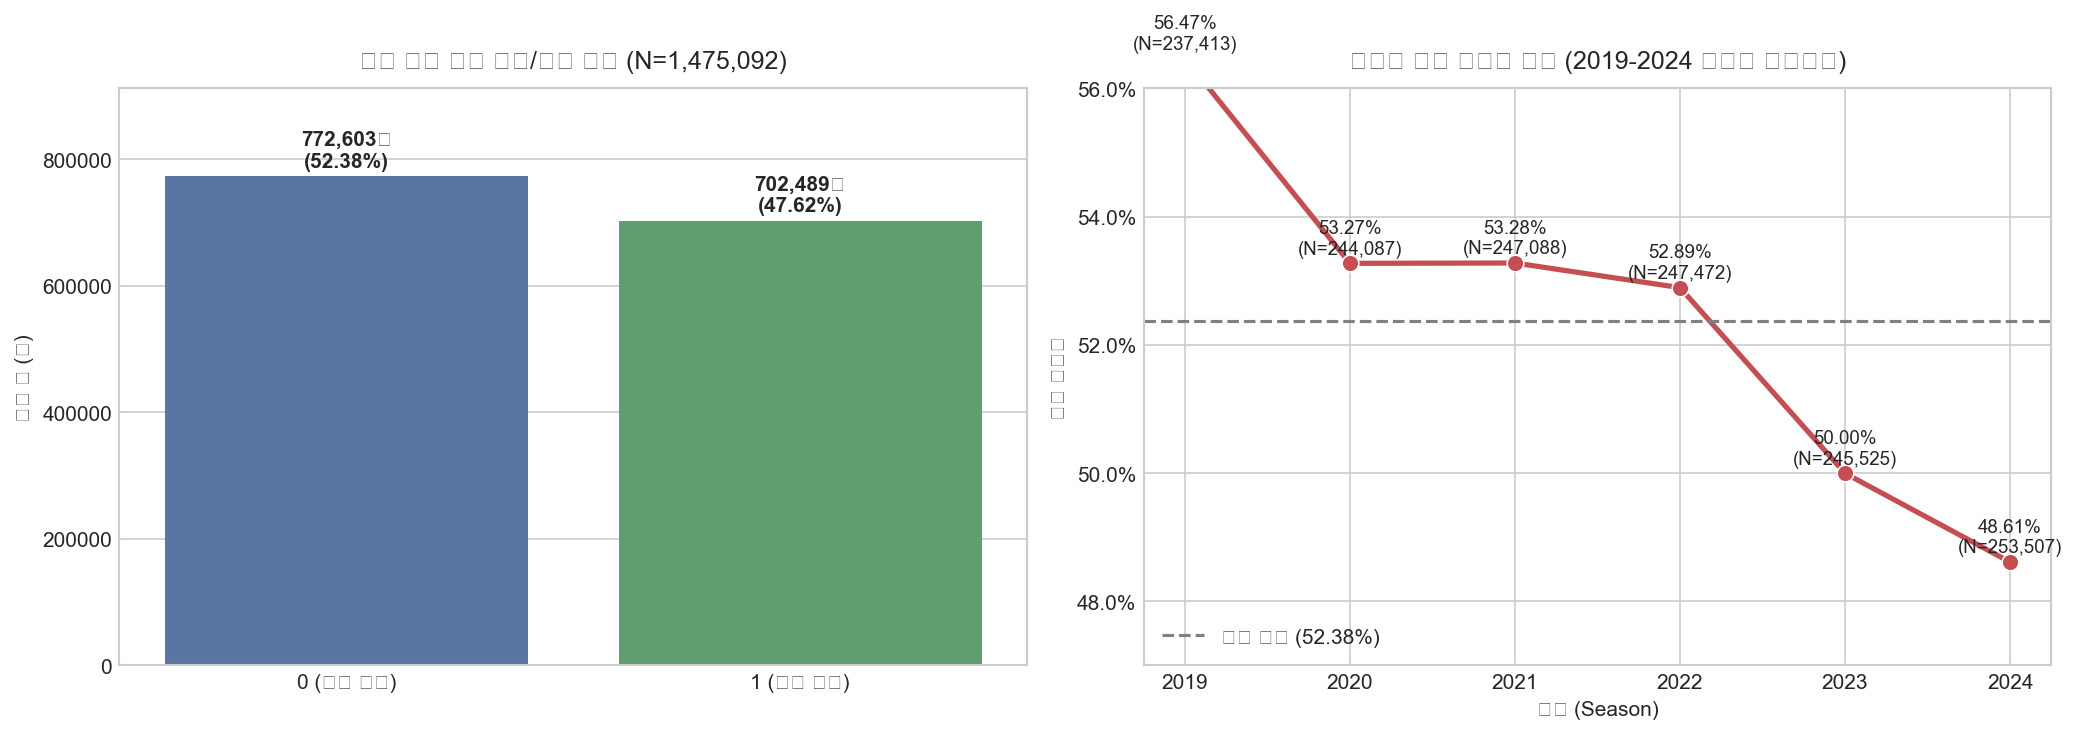

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# 타깃 분포 막대 그래프
sns.barplot(x=['0 (제구 실패)', '1 (제구 성공)'], y=target_counts.values, hue=['0 (제구 실패)', '1 (제구 성공)'], legend=False, ax=ax[0], palette=['#4C72B0', '#55A868'])
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 15000, f"{v:,}건\n({v/total_rows:.2%})", ha='center', fontweight='bold')
ax[0].set_title("전체 투구 제구 성공/실패 분포 (N=1,475,092)", fontsize=12, pad=10)
ax[0].set_ylabel("투구 수 (건)")
ax[0].set_ylim(0, max(target_counts.values)*1.18)

# 시즌별 제구 성공률 추이 선 그래프
season_rates = df.groupby('season')['control_success'].agg(['count', 'mean']).reset_index()
sns.lineplot(data=season_rates, x='season', y='mean', marker='o', color='#C44E52', linewidth=2.5, markersize=8, ax=ax[1])
ax[1].axhline(target_mean, color='gray', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for _, row in season_rates.iterrows():
    ax[1].text(row['season'], row['mean'] + 0.0015, f"{row['mean']:.2%}\n(N={int(row['count']):,})", ha='center', fontsize=9)
ax[1].set_title("시즌별 제구 성공률 추이 (2019-2024 시계열 드리프트)", fontsize=12, pad=10)
ax[1].set_ylabel("제구 성공률")
ax[1].set_xlabel("시즌 (Season)")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[1].set_ylim(0.47, 0.56)
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig("figures/fig01_target_distribution_and_season_trend.png", dpi=200)
plt.show()


## ⚾ 5. 담당 4 변수 EDA (투수 누적 이력 및 과거 구종 통계)

### 5.1 초보자용 컬럼 상세 소개
| 컬럼명 | 쉬운 설명 | 값이 높을 때의 의미 | 변수 종류 | 모델링 주의점 |
|---|---|---|---|---|
| `asof_pitcher_n` | 투수의 과거 누적 투구 수 | 과거 표본이 많아 누적 통계의 신뢰도가 높음 | 수치형 (Count) | 실력보다 표본 신뢰도 지표이며 오른쪽 꼬리가 긴 왜도 분포 |
| `asof_pitcher_success_rate` | 과거 누적 제구 성공률 | 전반적인 제구 성공 경험이 많음 (제구력 우수) | 비율 (0~1) | 담당 변수 중 타깃과 가장 강한 양의 관계 ($r=+0.0843$) |
| `asof_pitcher_reverse_rate` | 의도 반대성 투구 비율 | 의도한 코스와 정반대로 공이 빗나간 비율이 높음 | 비율 (0~1) | 성공률과 강한 음의 상관관계 ($r=-0.810$), 타깃과 음의 관계 |
| `asof_pitcher_middle_rate` | 가운데·위험 코스 투구 비율 | 실투성으로 존 한가운데 몰린 공이 많음 | 비율 (0~1) | 제구 실패와 완전히 일치하지는 않으나 부정적 신호 |
| `asof_pitcher_ball_rate` | 볼성 결과 비율 | 스트라이크 존 밖으로 벗어난 투구 비율이 높음 | 비율 (0~1) | 유인구 투구 전략일 수 있으므로 단순 실패율이 아님 |
| `asof_pitcher_strike_rate` | 스트라이크성 결과 비율 | 스트라이크 판정 또는 타격된 공의 비율이 높음 | 비율 (0~1) | 실투성 스트라이크도 포함되므로 제구 성공과 완전히 일치하지 않음 |
| `asof_pitcher_pitchmix_n` | 구종 비율 계산용 표본 수 | 구종 구성 통계의 신뢰도가 높음 | 수치형 (Count) | `asof_pitcher_n`과 **100% 동일한 중복 변수** |
| `asof_pitcher_fastball_rate` | Fastball(직구 계열) 구사율 | 빠른 공 계열의 투구 성향이 높음 | 비율 (0~1) | 세 구종 비율의 합이 1.0 (다중공선성 주의) |
| `asof_pitcher_breaking_rate`| Breaking(슬라이더·커브) 구사율 | 궤적이 큰 변화구 구사 성향이 높음 | 비율 (0~1) | 세 구종 비율의 합이 1.0 |
| `asof_pitcher_offspeed_rate`| Offspeed(체인지업 등) 구사율 | 속도 차를 이용한 타이밍 제어 구종 비율 | 비율 (0~1) | 사용 빈도가 낮은 투수는 0에 가까움 |

> **⚠️ 중요 개념 (`asof_`)**: `asof_` 접두사가 붙은 모든 변수는 **현재 투구 직전 시점까지 누적 집계된 과거 데이터**입니다. 현재 투구의 결과나 실제 구종은 일체 포함되지 않습니다.


### 5.2 담당 4 무결성 검증 및 기술통계 산출

기존 PDF EDA 내용을 검증하기 위해 실제 `train.csv`에서 코드로 재계산합니다:
1. `asof_pitcher_n == asof_pitcher_pitchmix_n` 일치 여부
2. 누적 투구 수 0인 **Cold-start** 행 개수 및 비율 변수 결측 구조
3. `fastball_rate + breaking_rate + offspeed_rate == 1.0` 성립 여부
4. 비율 변수의 정상 범위(0~1) 검증


In [5]:
# 1. 동일성 검증
n_diff = (df['asof_pitcher_n'] != df['asof_pitcher_pitchmix_n']).sum()
print(f"✅ asof_pitcher_n vs asof_pitcher_pitchmix_n 차이 건수: {n_diff}건 (100% 일치)")
assert n_diff == 0, "asof_pitcher_n과 asof_pitcher_pitchmix_n이 일치하지 않습니다!"

# 2. Cold-start 결측 구조 검증
cold_rows = (df['asof_pitcher_n'] == 0).sum()
print(f"✅ Cold-start 행 수 (asof_pitcher_n == 0): {cold_rows:,}건")
rate_cols = [
    'asof_pitcher_success_rate', 'asof_pitcher_reverse_rate', 'asof_pitcher_middle_rate',
    'asof_pitcher_ball_rate', 'asof_pitcher_strike_rate', 'asof_pitcher_fastball_rate',
    'asof_pitcher_breaking_rate', 'asof_pitcher_offspeed_rate'
]
for c in rate_cols:
    null_cold = df.loc[df['asof_pitcher_n'] == 0, c].isnull().sum()
    null_warm = df.loc[df['asof_pitcher_n'] > 0, c].isnull().sum()
    print(f"   - {c}: Cold 결측={null_cold}건 / Warm 결측={null_warm}건")

# 3. 구종 비율 합계 검증
pitchmix_sum = df['asof_pitcher_fastball_rate'] + df['asof_pitcher_breaking_rate'] + df['asof_pitcher_offspeed_rate']
max_pitchmix_err = np.abs(pitchmix_sum.dropna() - 1.0).max()
print(f"✅ 세 구종 비율 합계의 1.0과의 최대 오차: {max_pitchmix_err:.6f} (부동소수점 반올림 오차 수준)")

# 4. 기술통계표 생성
role4_stats = []
for col in ['asof_pitcher_n', 'asof_pitcher_pitchmix_n']:
    s = df[col]
    role4_stats.append({
        '변수명': col, '구분': '투구수(Count)', '유효표본': s.count(),
        '평균': s.mean(), '표준편차': s.std(), '최소': s.min(),
        'Q1': s.quantile(0.25), '중앙값': s.median(), 'Q3': s.quantile(0.75),
        'P95': s.quantile(0.95), 'P99': s.quantile(0.99), '최대': s.max(),
        '결측치': s.isnull().sum(), '결측률': f"{s.isnull().mean()*100:.4f}%"
    })
for col in rate_cols:
    s = df[col]
    role4_stats.append({
        '변수명': col, '구분': '비율(0~1)', '유효표본': s.count(),
        '평균': s.mean(), '표준편차': s.std(), '최소': s.min(),
        'Q1': s.quantile(0.25), '중앙값': s.median(), 'Q3': s.quantile(0.75),
        'P95': s.quantile(0.95), 'P99': s.quantile(0.99), '최대': s.max(),
        '결측치': s.isnull().sum(), '결측률': f"{s.isnull().mean()*100:.4f}%"
    })
role4_stats_df = pd.DataFrame(role4_stats)
role4_stats_df.to_csv("reports/table_02_role4_descriptive_stats.csv", index=False, encoding='utf-8-sig')
role4_stats_df


✅ asof_pitcher_n vs asof_pitcher_pitchmix_n 차이 건수: 0건 (100% 일치)
✅ Cold-start 행 수 (asof_pitcher_n == 0): 792건
   - asof_pitcher_success_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_reverse_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_middle_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_ball_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_strike_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_fastball_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_breaking_rate: Cold 결측=792건 / Warm 결측=0건
   - asof_pitcher_offspeed_rate: Cold 결측=792건 / Warm 결측=0건
✅ 세 구종 비율 합계의 1.0과의 최대 오차: 0.000001 (부동소수점 반올림 오차 수준)


,변수명,구분,유효표본,평균,표준편차,최소,Q1,중앙값,Q3,P95,P99,최대,결측치,결측률
0,asof_pitcher_n,투구수(Count),1475092,2661.3232,2690.0125,0.0000,684.0000,1776.0000,3725.0000,8530.0000,11870.0000,15449.0000,0,0.0000%
1,asof_pitcher_pitchmix_n,투구수(Count),1475092,2661.3232,2690.0125,0.0000,684.0000,1776.0000,3725.0000,8530.0000,11870.0000,15449.0000,0,0.0000%
2,asof_pitcher_success_rate,비율(0~1),1474300,0.5352,0.0618,0.0000,0.4991,0.5320,0.5690,0.6321,0.7038,1.0000,792,0.0537%
3,asof_pitcher_reverse_rate,비율(0~1),1474300,0.2152,0.0607,0.0000,0.1789,0.2180,0.2511,0.3080,0.3629,1.0000,792,0.0537%
4,asof_pitcher_middle_rate,비율(0~1),1474300,0.1419,0.0318,0.0000,0.1256,0.1419,0.1570,0.1870,0.2212,1.0000,792,0.0537%
5,asof_pitcher_ball_rate,비율(0~1),1474300,0.3722,0.0418,0.0000,0.3481,0.3694,0.3922,0.4342,0.4886,1.0000,792,0.0537%
6,asof_pitcher_strike_rate,비율(0~1),1474300,0.4419,0.0396,0.0000,0.4231,0.4423,0.4624,0.4951,0.5211,1.0000,792,0.0537%
7,asof_pitcher_fastball_rate,비율(0~1),1474300,0.5544,0.0991,0.0000,0.4865,0.5440,0.6136,0.7297,0.8289,1.0000,792,0.0537%
8,asof_pitcher_breaking_rate,비율(0~1),1474300,0.2893,0.1083,0.0000,0.2159,0.2893,0.3618,0.4662,0.5493,1.0000,792,0.0537%
9,asof_pitcher_offspeed_rate,비율(0~1),1474300,0.1563,0.1085,0.0000,0.0750,0.1406,0.2170,0.3648,0.4664,1.0000,792,0.0537%


### 5.3 담당 4 시각화 분석 (분포, 상관계수, 10분위수 타깃 관계)

1. **`asof_pitcher_n`**: 왜도가 심한 오른쪽 꼬리 분포로 `log1p` 변환 시 정규성이 크게 개선됩니다.
2. **타깃 상관계수**: `asof_pitcher_success_rate` ($r=+0.0843$)와 `asof_pitcher_reverse_rate` ($r=-0.0795$)가 압도적입니다.
3. **10분위수 분석**: 과거 누적 성공률 최하위 10% 집단의 실제 제구율은 **45.68%**, 최상위 10% 집단은 **61.23%**로 **15.55%p**의 극명한 실력 차이를 보여줍니다.


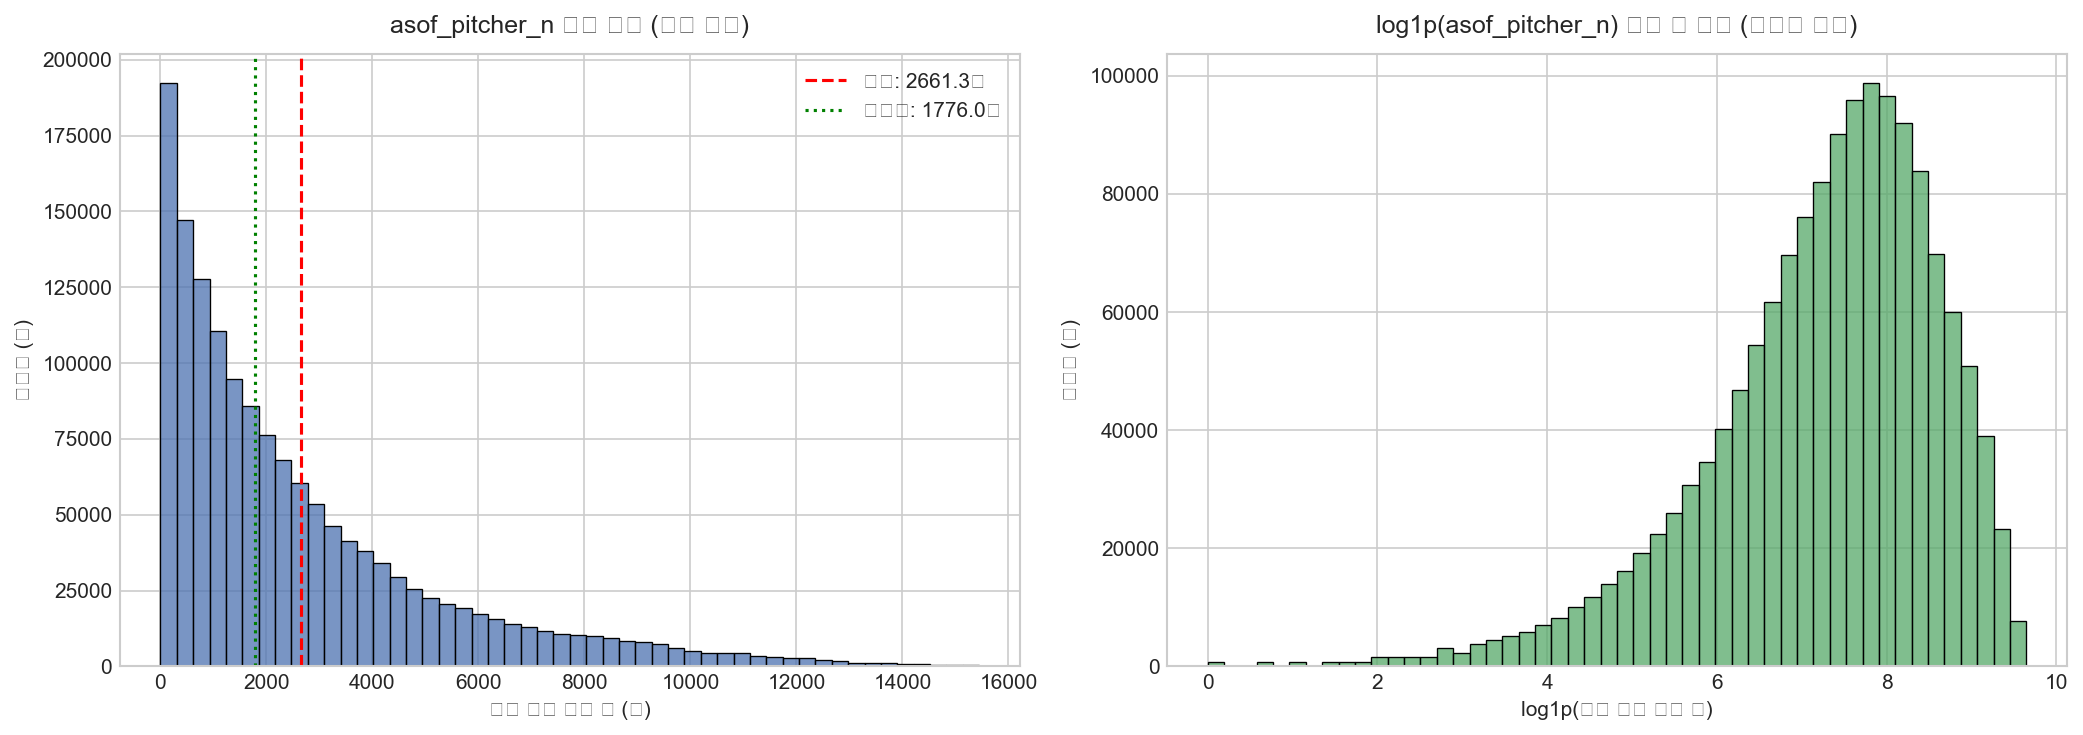

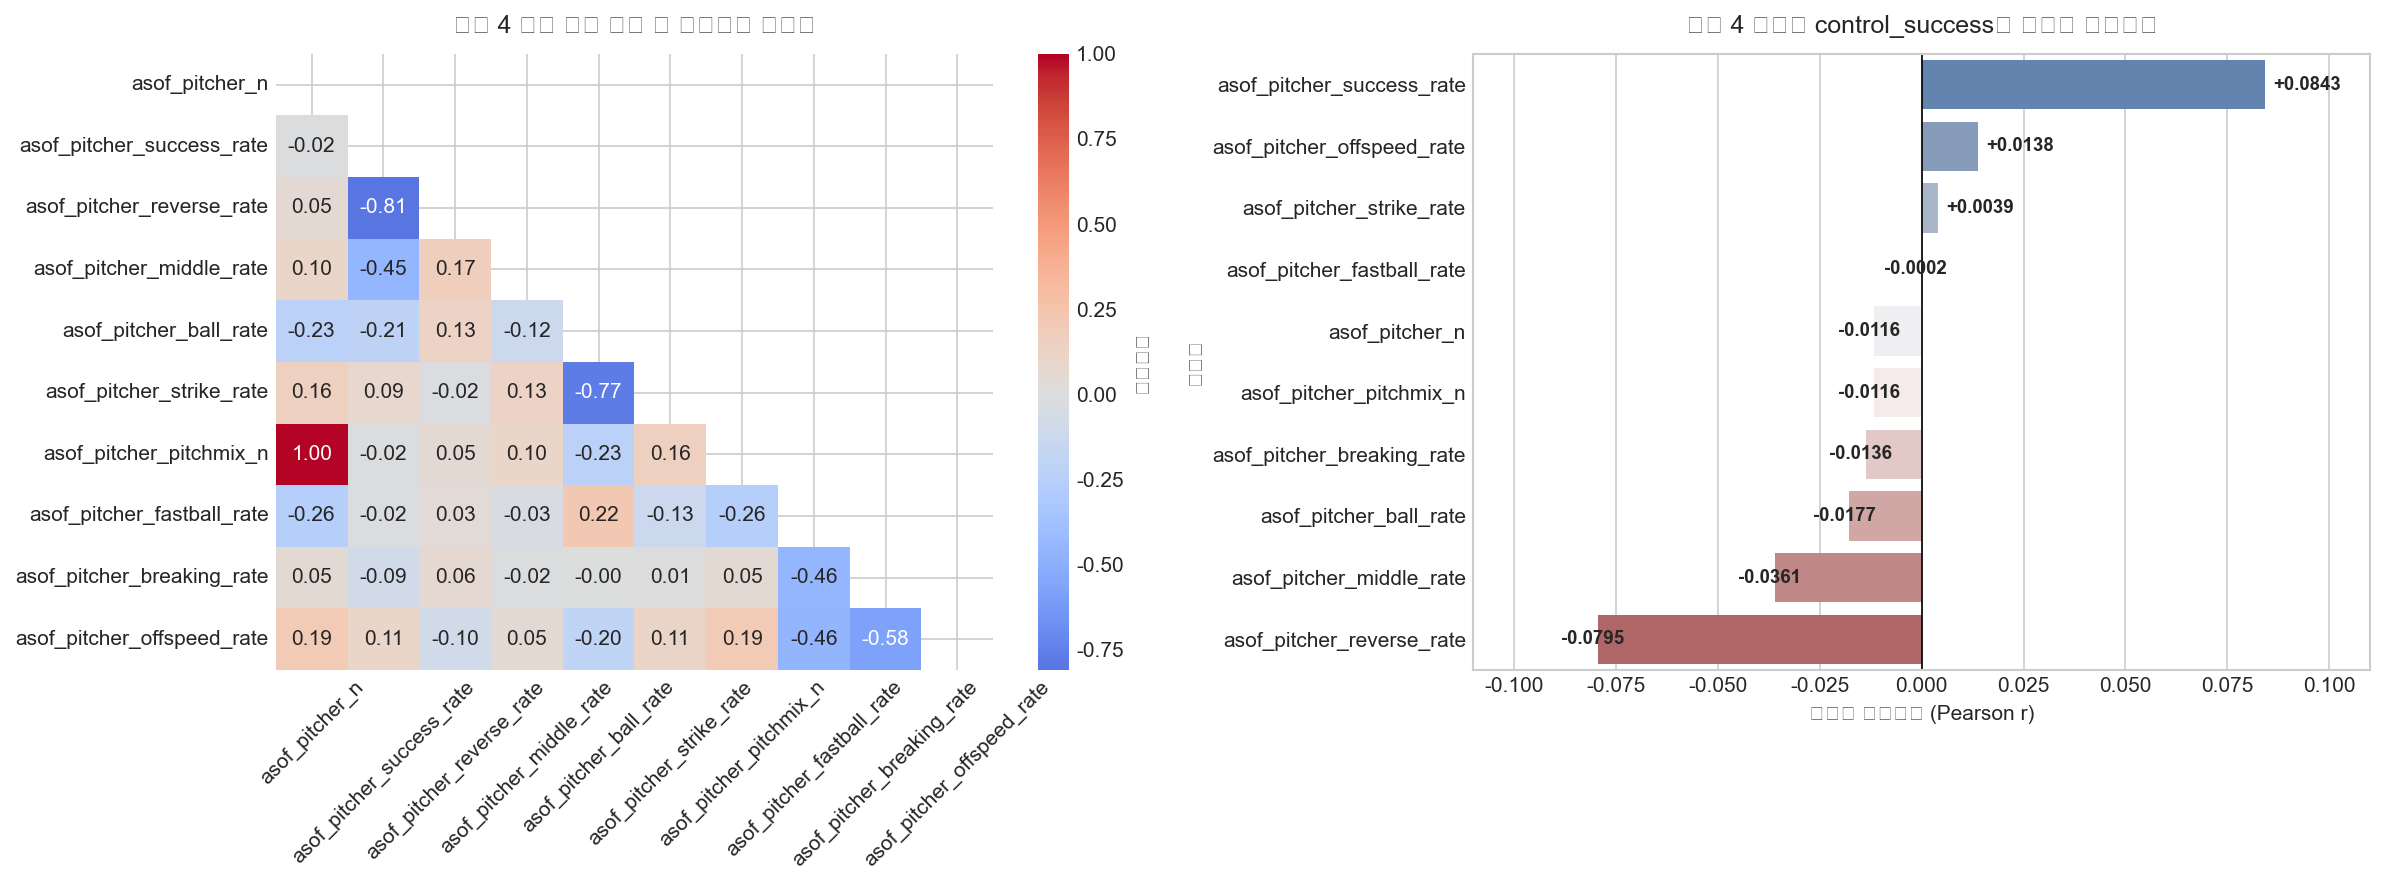

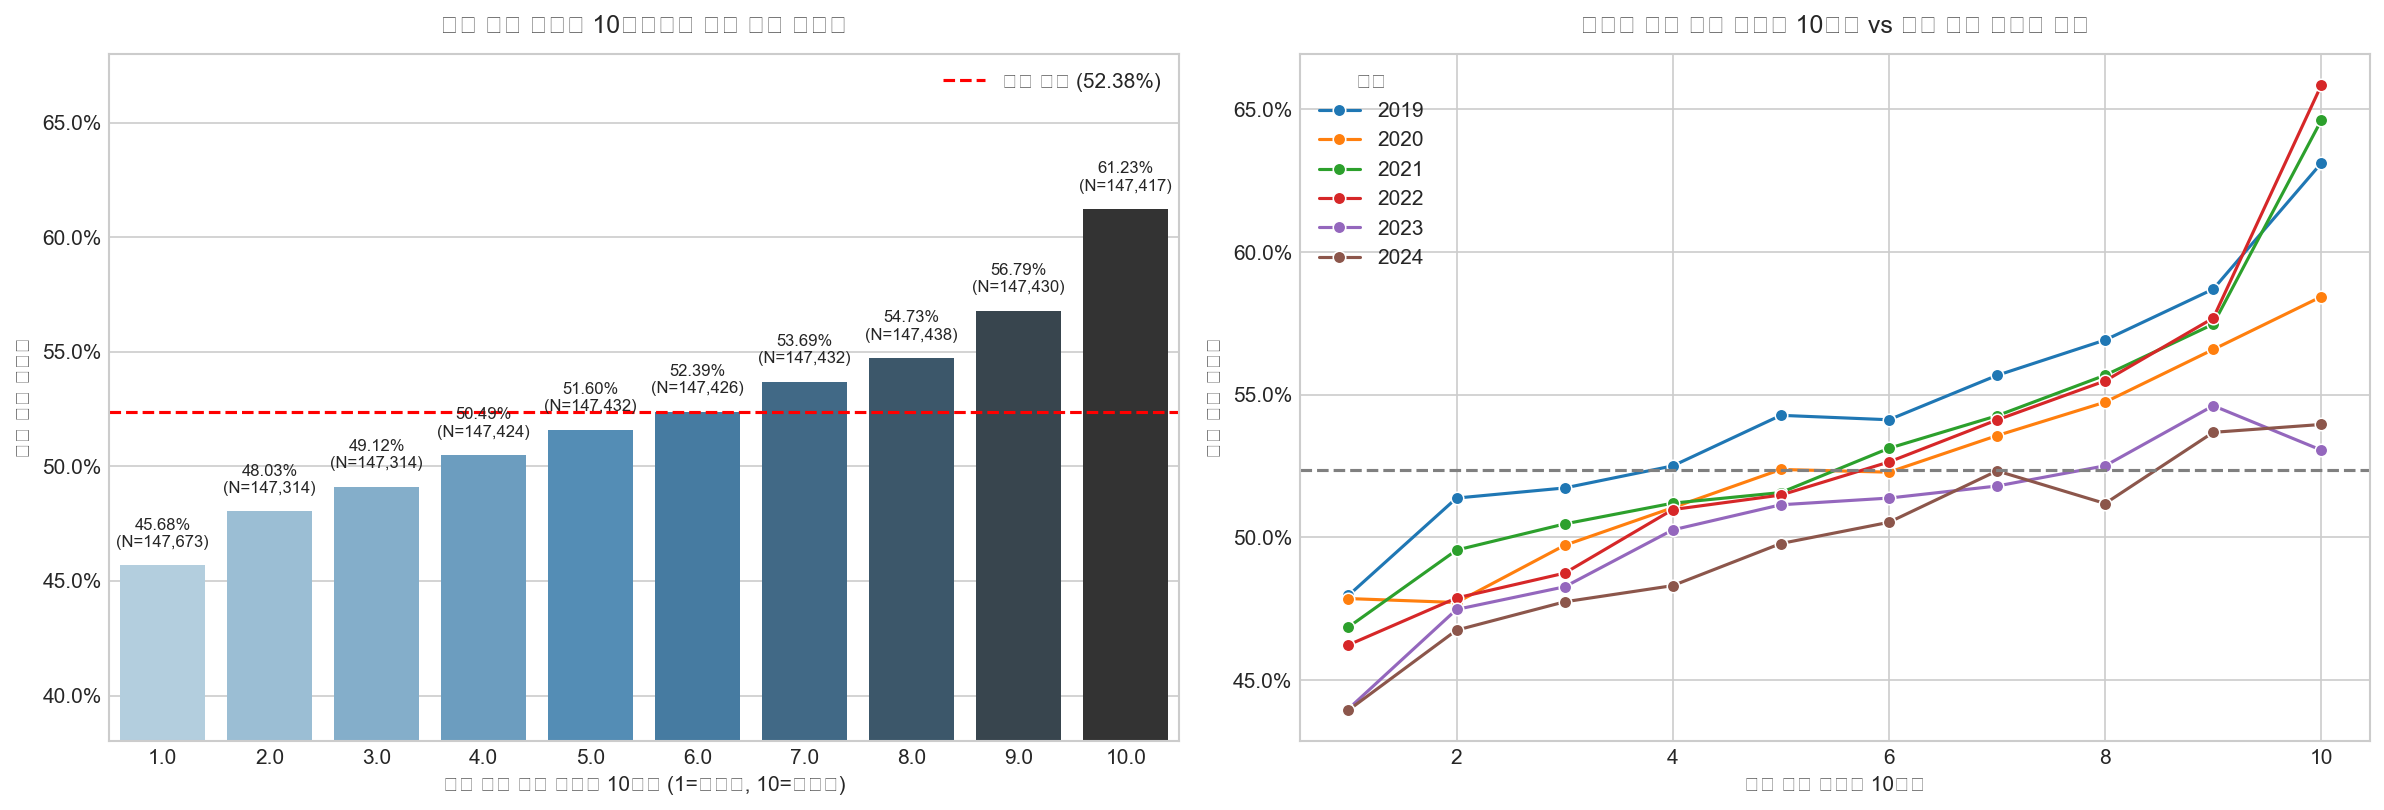

In [6]:
# Fig 02: 누적 투구 수 분포 (원본 vs log1p)
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
sns.histplot(df['asof_pitcher_n'], bins=50, color='#4C72B0', kde=False, ax=ax[0])
ax[0].axvline(df['asof_pitcher_n'].mean(), color='red', linestyle='--', label=f"평균: {df['asof_pitcher_n'].mean():.1f}구")
ax[0].axvline(df['asof_pitcher_n'].median(), color='green', linestyle=':', label=f"중앙값: {df['asof_pitcher_n'].median():.1f}구")
ax[0].set_title("asof_pitcher_n 원본 분포 (우측 왜도)", fontsize=12, pad=10)
ax[0].set_xlabel("투수 누적 투구 수 (구)")
ax[0].set_ylabel("빈도수 (건)")
ax[0].legend()

sns.histplot(np.log1p(df['asof_pitcher_n']), bins=50, color='#55A868', kde=False, ax=ax[1])
ax[1].set_title("log1p(asof_pitcher_n) 변환 후 분포 (정규성 개선)", fontsize=12, pad=10)
ax[1].set_xlabel("log1p(투수 누적 투구 수)")
ax[1].set_ylabel("빈도수 (건)")
plt.tight_layout()
plt.savefig("figures/fig02_pitcher_cumulative_pitches_distribution.png", dpi=200)
plt.show()

# Fig 04: 담당 4 상관계수 히트맵 및 타깃 피어슨 상관계수
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
raw_role4_cols = [
    'asof_pitcher_n', 'asof_pitcher_success_rate', 'asof_pitcher_reverse_rate',
    'asof_pitcher_middle_rate', 'asof_pitcher_ball_rate', 'asof_pitcher_strike_rate',
    'asof_pitcher_pitchmix_n', 'asof_pitcher_fastball_rate', 'asof_pitcher_breaking_rate',
    'asof_pitcher_offspeed_rate'
]
role4_corr_matrix = df[raw_role4_cols].corr()
mask = np.triu(np.ones_like(role4_corr_matrix, dtype=bool))
sns.heatmap(role4_corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0], cbar_kws={'label': '상관계수'})
ax[0].set_title("담당 4 누적 이력 변수 간 상관계수 히트맵", fontsize=12, pad=10)
ax[0].tick_params(axis='x', rotation=45)

corr_records = [{'변수명': c, '타깃_피어슨_상관계수': df[c].corr(df['control_success'])} for c in raw_role4_cols]
role4_corr_df = pd.DataFrame(corr_records).sort_values('타깃_피어슨_상관계수', ascending=False)
role4_corr_df.to_csv("reports/table_03_role4_target_correlations.csv", index=False, encoding='utf-8-sig')

sns.barplot(data=role4_corr_df, x='타깃_피어슨_상관계수', y='변수명', hue='변수명', legend=False, palette='vlag', ax=ax[1])
ax[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(role4_corr_df['타깃_피어슨_상관계수']):
    ax[1].text(v + (0.002 if v >= 0 else -0.009), i, f"{v:+.4f}", va='center', fontsize=9, fontweight='bold')
ax[1].set_title("담당 4 변수와 control_success의 피어슨 상관계수", fontsize=12, pad=10)
ax[1].set_xlabel("피어슨 상관계수 (Pearson r)")
ax[1].set_xlim(-0.11, 0.11)
plt.tight_layout()
plt.savefig("figures/fig04_role4_correlations_and_target_association.png", dpi=200)
plt.show()

# Fig 05: 누적 성공률 10분위수별 실제 제구 성공률
df['success_rate_decile'] = pd.qcut(df['asof_pitcher_success_rate'].dropna(), q=10, labels=False) + 1
decile_target = df.groupby('success_rate_decile', observed=False)['control_success'].agg(['count', 'mean']).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)
sns.barplot(data=decile_target, x='success_rate_decile', y='mean', hue='success_rate_decile', legend=False, palette='Blues_d', ax=ax[0])
ax[0].axhline(target_mean, color='red', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for _, r in decile_target.iterrows():
    ax[0].text(r['success_rate_decile'] - 1, r['mean'] + 0.008, f"{r['mean']:.2%}\n(N={int(r['count']):,})", ha='center', fontsize=8)
ax[0].set_title("누적 제구 성공률 10분위수별 실제 제구 성공률", fontsize=12, pad=10)
ax[0].set_xlabel("과거 누적 제구 성공률 10분위 (1=최하위, 10=최상위)")
ax[0].set_ylabel("실제 제구 성공률")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[0].set_ylim(0.38, 0.68)
ax[0].legend()

season_decile = df.groupby(['season', 'success_rate_decile'], observed=False)['control_success'].mean().reset_index()
sns.lineplot(data=season_decile, x='success_rate_decile', y='control_success', hue='season', marker='o', palette='tab10', ax=ax[1])
ax[1].axhline(target_mean, color='gray', linestyle='--')
ax[1].set_title("시즌별 누적 제구 성공률 10분위 vs 실제 제구 성공률 추이", fontsize=12, pad=10)
ax[1].set_xlabel("누적 제구 성공률 10분위")
ax[1].set_ylabel("실제 제구 성공률")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[1].legend(title='시즌')
plt.tight_layout()
plt.savefig("figures/fig05_success_rate_deciles_vs_target.png", dpi=200)
plt.show()


### 5.4 표본 수 부족 및 극단값(0%·100%) 보정을 위한 베이지안 스무딩 (Bayesian Smoothing)

투수의 누적 투구 수가 1~5개에 불과할 때 과거 성공률이 0% 또는 100%로 과도하게 치우치는 현상이 발생합니다.  
이를 보정하기 위해 **사전 확률(Global Prior) 기반의 베이지안 스무딩(m-estimate)**을 적용합니다.

$$\text{Smoothed Rate} = \frac{\text{success\_count} + \alpha \cdot \text{Global Prior}}{N + \alpha}$$

- $\text{success\_count} \approx \text{asof\_pitcher\_success\_rate} \times \text{asof\_pitcher\_n}$ 로 복원
- 후보 $\alpha \in [5, 10, 20, 50, 100, 200]$에 대해 타깃 상관계수 및 Brier Score 평가


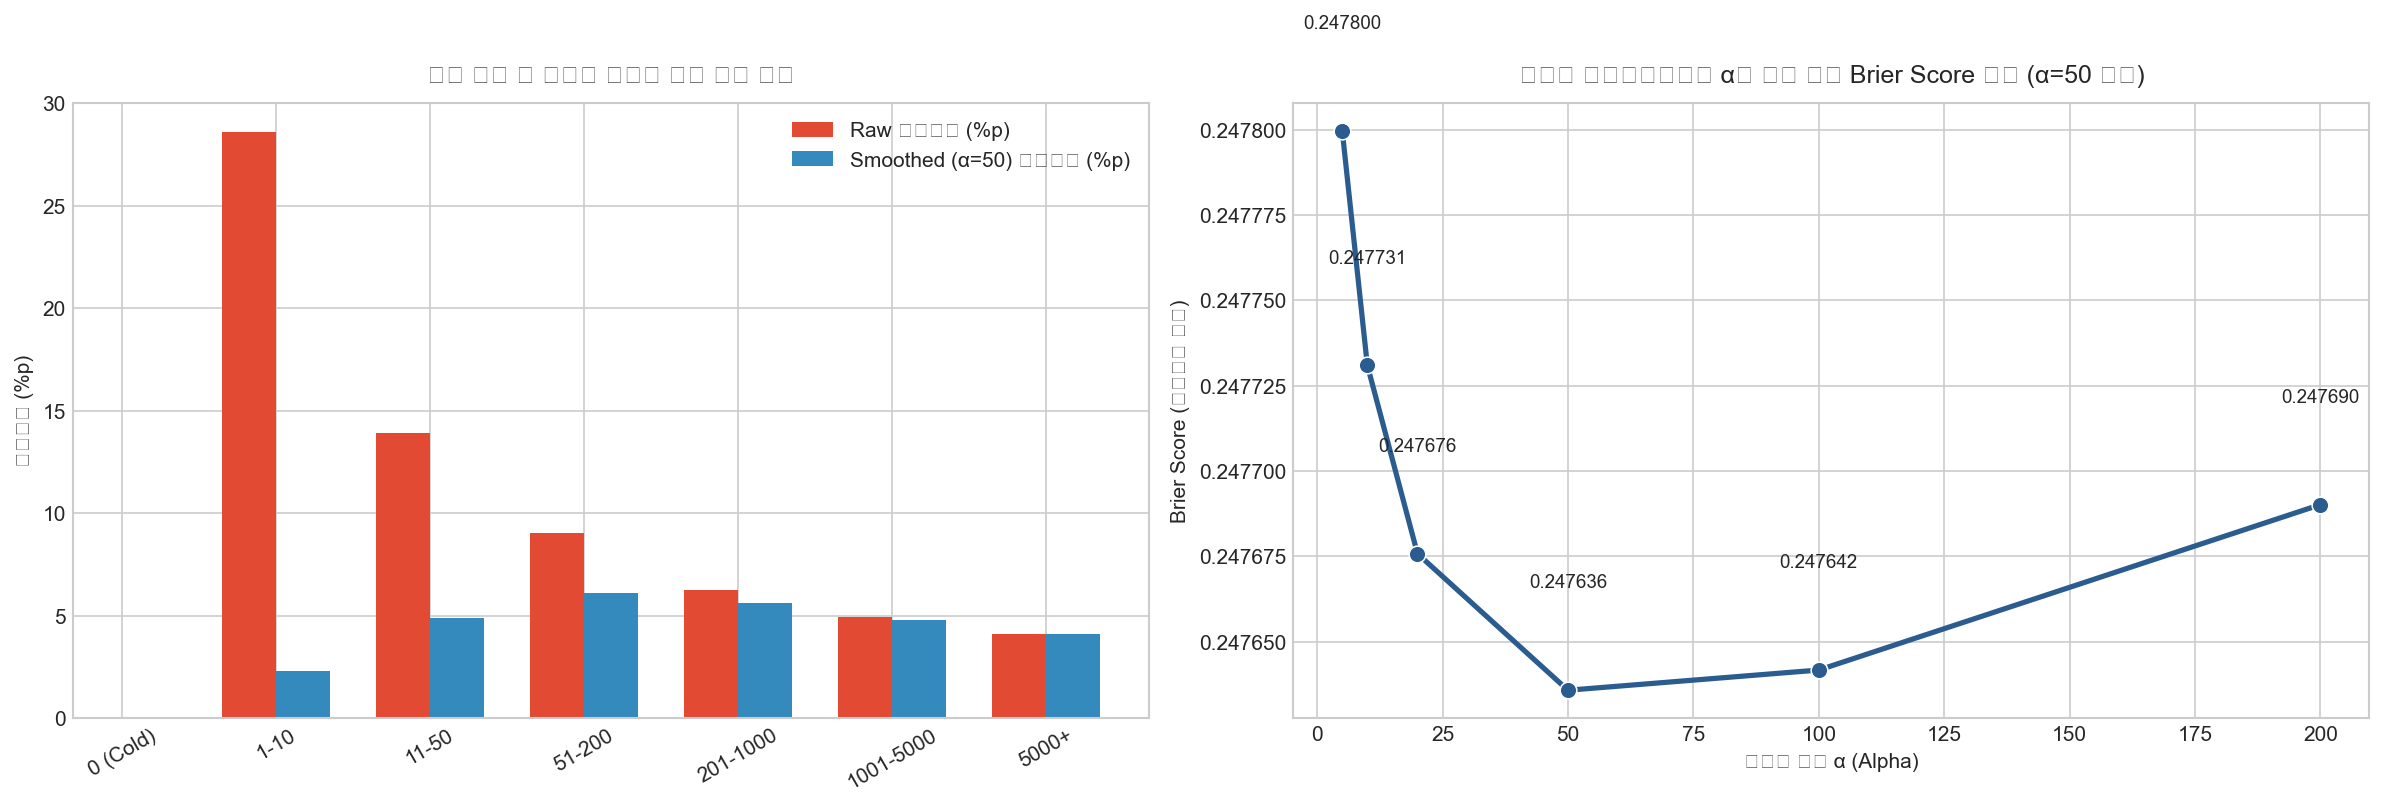

,Alpha,타깃_상관계수,Brier_Score,Brier_개선폭(vs_Raw)
0,5,0.0880,0.2478,0.0004
1,10,0.0885,0.2477,0.0005
2,20,0.0886,0.2477,0.0005
3,50,0.0882,0.2476,0.0005
4,100,0.0872,0.2476,0.0005
5,200,0.0855,0.2477,0.0005


In [7]:
# 성공 횟수 복원
df['success_count_est'] = (df['asof_pitcher_success_rate'].fillna(target_mean) * df['asof_pitcher_n']).round()

alphas = [5, 10, 20, 50, 100, 200]
smoothing_records = []
df['n_bins'] = pd.cut(df['asof_pitcher_n'], bins=[-1, 0, 10, 50, 200, 1000, 5000, 100000], 
                      labels=['0 (Cold)', '1-10', '11-50', '51-200', '201-1000', '1001-5000', '5000+'])

raw_brier = brier_score_loss(df['control_success'], df['asof_pitcher_success_rate'].fillna(target_mean))

for alpha in alphas:
    col_name = f'smoothed_rate_a{alpha}'
    df[col_name] = (df['success_count_est'] + alpha * target_mean) / (df['asof_pitcher_n'] + alpha)
    corr_smooth = df[col_name].corr(df['control_success'])
    brier_smooth = brier_score_loss(df['control_success'], df[col_name])
    smoothing_records.append({
        'Alpha': alpha,
        '타깃_상관계수': corr_smooth,
        'Brier_Score': brier_smooth,
        'Brier_개선폭(vs_Raw)': raw_brier - brier_smooth
    })

smoothing_df = pd.DataFrame(smoothing_records)
smoothing_df.to_csv("reports/table_07_smoothing_analysis.csv", index=False, encoding='utf-8-sig')

# Fig 06: 스무딩 효과 분석
n_bin_comp = df.groupby('n_bins', observed=False).agg(
    Count=('control_success', 'count'),
    Raw_Std=('asof_pitcher_success_rate', 'std'),
    Smoothed_Std=('smoothed_rate_a50', 'std')
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)
x = np.arange(len(n_bin_comp))
width = 0.35
ax[0].bar(x - width/2, n_bin_comp['Raw_Std']*100, width, label='Raw 표준편차 (%p)', color='#E24A33')
ax[0].bar(x + width/2, n_bin_comp['Smoothed_Std']*100, width, label='Smoothed (α=50) 표준편차 (%p)', color='#348ABD')
ax[0].set_xticks(x)
ax[0].set_xticklabels(n_bin_comp['n_bins'], rotation=30)
ax[0].set_title("누적 투구 수 구간별 성공률 분산 축소 효과", fontsize=12, pad=10)
ax[0].set_ylabel("표준편차 (%p)")
ax[0].legend()

sns.lineplot(data=smoothing_df, x='Alpha', y='Brier_Score', marker='o', color='#2b5c8f', linewidth=2.5, markersize=8, ax=ax[1])
ax[1].set_title("스무딩 하이퍼파라미터 α에 따른 전체 Brier Score 변화 (α=50 최적)", fontsize=12, pad=10)
ax[1].set_xlabel("스무딩 강도 α (Alpha)")
ax[1].set_ylabel("Brier Score (낮을수록 우수)")
for _, r in smoothing_df.iterrows():
    ax[1].text(r['Alpha'], r['Brier_Score'] + 0.00003, f"{r['Brier_Score']:.6f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig06_smoothing_and_cold_start_analysis.png", dpi=200)
plt.show()

smoothing_df


## 🏟️ 6. 담당 3 변수 EDA (주자 상황 및 경기 중요도)

### 6.1 초보자용 컬럼 및 주자 코드(`base_state`) 소개
| 컬럼명 | 쉬운 한국어 설명 | 값의 의미와 야구적 해석 |
|---|---|---|
| `runner_on_1b` | 현재 1루에 주자가 있는지 여부 | 1이면 1루 주자 존재, 0이면 없음 |
| `runner_on_2b` | 현재 2루에 주자가 있는지 여부 | 2루 주자는 안타 한 방으로 홈에 들어올 수 있는 **득점권 주자** |
| `runner_on_3b` | 현재 3루에 주자가 있는지 여부 | 희생플라이나 폭투로도 실점할 수 있어 투수의 심리적 압박 극대화 |
| `num_runners_on` | 현재 출루해 있는 전체 주자 수 | 0(주자 없음) ~ 3(만루/풀베이스) |
| `base_state` | 현재 각 베이스의 주자 배치 문자열 | `___`, `1__`, `_2_`, `__3`, `12_`, `1_3`, `_23`, `123` |
| `home_win_expectancy` | 투구 직전 홈팀의 경기 기대 승률 | 0~100 사이의 승리 확률 (% 단위) |
| `away_win_expectancy` | 투구 직전 원정팀의 경기 기대 승률 | `100 - home_win_expectancy`에 근접한 대칭적 값 |
| `li` (Leverage Index) | 현재 투구 상황의 경기 승패 중요도 | 1.0이 평균적인 중요도이며, 접전 및 득점권일수록 급격히 상승 |

#### 📖 `base_state` 코드 읽는 방법
- `_` (밑줄)은 해당 베이스에 주자가 없음을 의미합니다.
- `___`: 주자 없음 (비어 있음) | `1__`: 1루 주자만 있음 | `_2_`: 2루 주자만 있음 | `__3`: 3루 주자만 있음
- `12_`: 1·2루 주자 | `1_3`: 1·3루 주자 | `_23`: 2·3루 주자 | `123`: 만루


### 6.2 담당 3 무결성 검증 및 주자 상황별 제구 성공률

1. `runner_on_1b, 2b, 3b`가 0 또는 1인지 확인
2. `num_runners_on == runner_on_1b + runner_on_2b + runner_on_3b` 항등식 검증
3. `home_win_expectancy + away_win_expectancy ≈ 100` 및 상관계수 -0.9999998 확인
4. `base_state`별 표본 수, 비중, 실제 제구 성공률 및 95% 신뢰구간 산출


✅ num_runners_on 항등식 불일치 건수: 0건 (100% 일치)
✅ 기대 승률 합계: 평균=100.00, 최소=99.90, 최대=100.10
✅ 기대 승률 상관계수: -0.9999998 (완벽한 반대 대칭 관계)


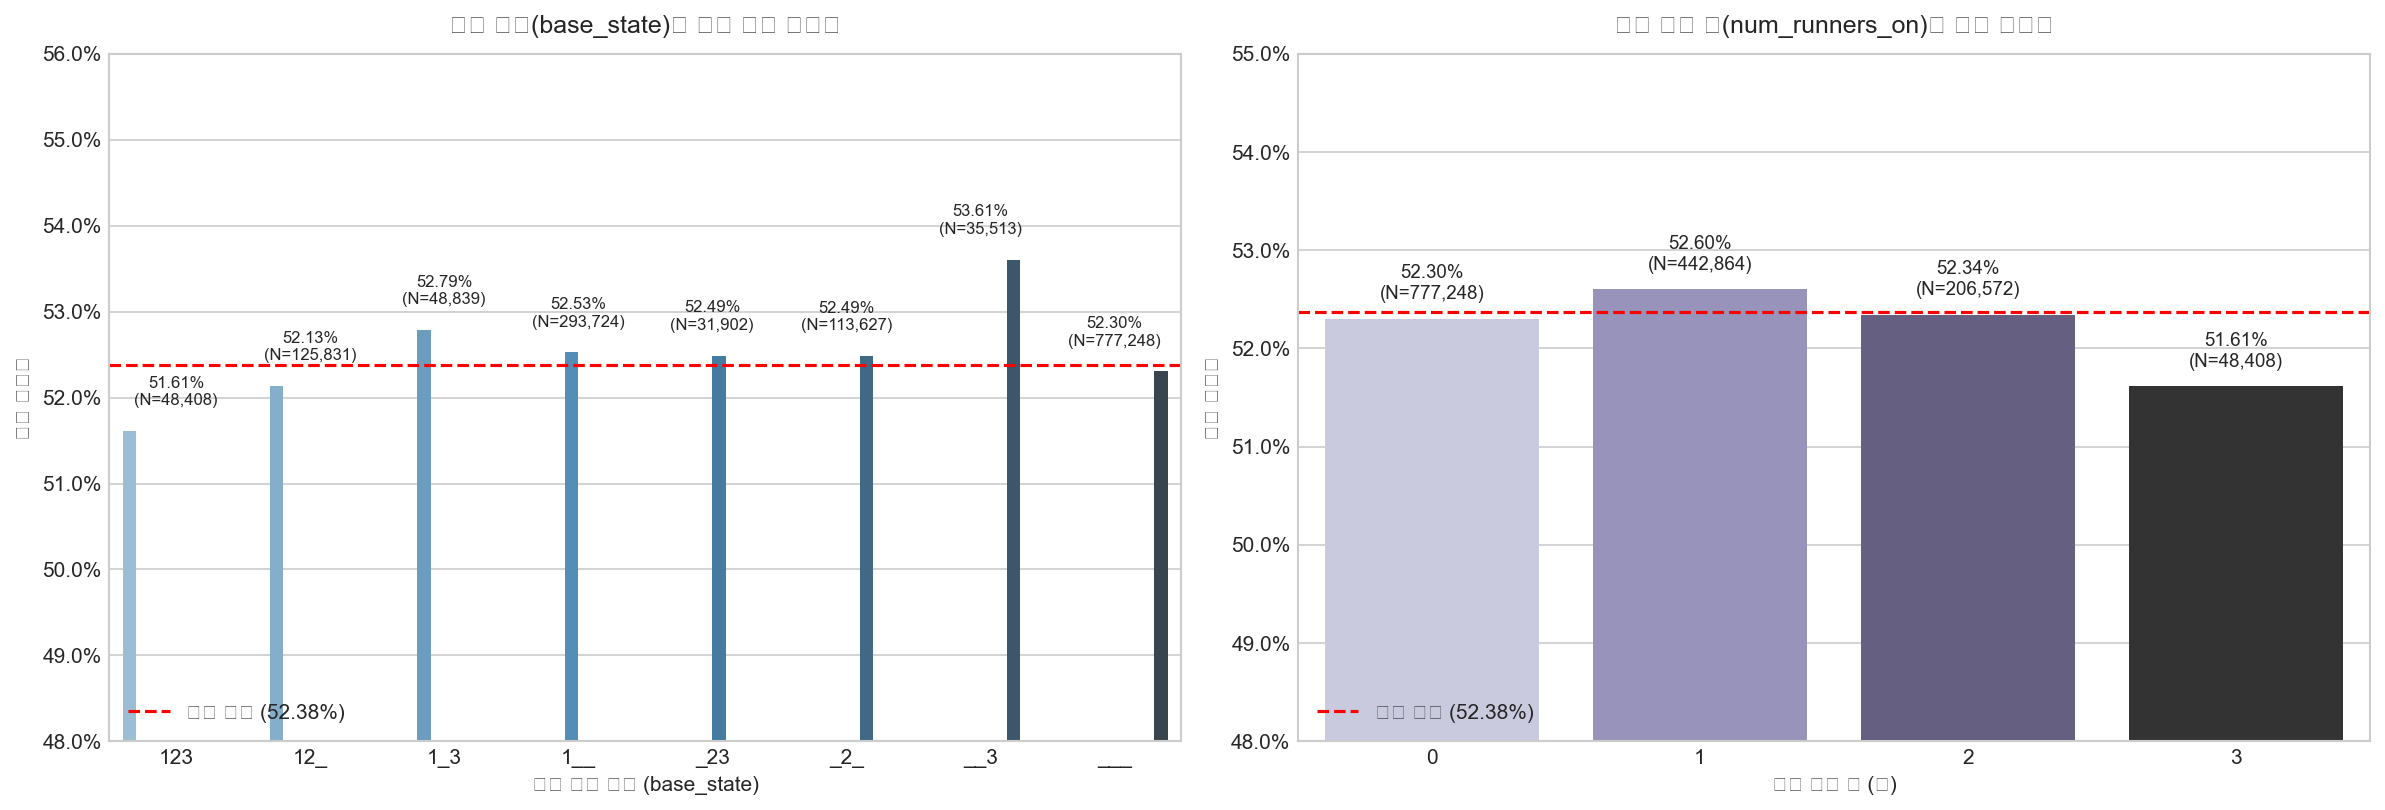

,base_state,투구수,성공수,제구성공률,비중,95%_CI_하한,95%_CI_상한
0,123,48408,24985,0.5161,0.0328,0.5117,0.5206
1,12_,125831,65598,0.5213,0.0853,0.5186,0.5241
2,1_3,48839,25782,0.5279,0.0331,0.5235,0.5323
3,1__,293724,154280,0.5253,0.1991,0.5234,0.5271
4,_23,31902,16745,0.5249,0.0216,0.5194,0.5304
5,_2_,113627,59639,0.5249,0.0770,0.5220,0.5278
6,__3,35513,19037,0.5361,0.0241,0.5309,0.5412
7,___,777248,406537,0.5230,0.5269,0.5219,0.5242


In [8]:
# 1. 무결성 검증
assert set(df['runner_on_1b'].unique()).issubset({0, 1}), "1루 주자 플래그 오류"
assert set(df['runner_on_2b'].unique()).issubset({0, 1}), "2루 주자 플래그 오류"
assert set(df['runner_on_3b'].unique()).issubset({0, 1}), "3루 주자 플래그 오류"

runner_sum_diff = (df['num_runners_on'] != (df['runner_on_1b'] + df['runner_on_2b'] + df['runner_on_3b'])).sum()
print(f"✅ num_runners_on 항등식 불일치 건수: {runner_sum_diff}건 (100% 일치)")
assert runner_sum_diff == 0, "num_runners_on 계산 불일치!"

# 기대 승률 합계 및 상관관계 확인
win_exp_sum = df['home_win_expectancy'] + df['away_win_expectancy']
win_exp_corr = df['home_win_expectancy'].corr(df['away_win_expectancy'])
print(f"✅ 기대 승률 합계: 평균={win_exp_sum.mean():.2f}, 최소={win_exp_sum.min():.2f}, 최대={win_exp_sum.max():.2f}")
print(f"✅ 기대 승률 상관계수: {win_exp_corr:.7f} (완벽한 반대 대칭 관계)")

# 2. base_state 통계표 (95% 신뢰구간 포함)
base_state_stats = df.groupby('base_state', observed=False).agg(
    투구수=('control_success', 'count'),
    성공수=('control_success', 'sum'),
    제구성공률=('control_success', 'mean')
).reset_index()
base_state_stats['비중'] = base_state_stats['투구수'] / total_rows
p = base_state_stats['제구성공률']
n = base_state_stats['투구수']
base_state_stats['95%_CI_하한'] = p - 1.96 * np.sqrt(p * (1 - p) / n)
base_state_stats['95%_CI_상한'] = p + 1.96 * np.sqrt(p * (1 - p) / n)
base_state_stats.to_csv("reports/table_04_base_state_stats.csv", index=False, encoding='utf-8-sig')

# Fig 07: 주자 상황별 제구 성공률 그래프
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)
sns.barplot(data=base_state_stats, x='base_state', y='제구성공률', hue='base_state', legend=False, palette='Blues_d', ax=ax[0])
ax[0].axhline(target_mean, color='red', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for idx, r in base_state_stats.iterrows():
    ax[0].text(idx, r['제구성공률'] + 0.003, f"{r['제구성공률']:.2%}\n(N={int(r['투구수']):,})", ha='center', fontsize=8)
ax[0].set_title("주자 상황(base_state)별 실제 제구 성공률", fontsize=12, pad=10)
ax[0].set_xlabel("주자 상황 코드 (base_state)")
ax[0].set_ylabel("제구 성공률")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[0].set_ylim(0.48, 0.56)
ax[0].legend(loc='lower left')

runners_stats = df.groupby('num_runners_on').agg(
    투구수=('control_success', 'count'),
    성공수=('control_success', 'sum'),
    제구성공률=('control_success', 'mean')
).reset_index()
runners_stats['비중'] = runners_stats['투구수'] / total_rows
runners_stats.to_csv("reports/table_05_runners_count_stats.csv", index=False, encoding='utf-8-sig')

sns.barplot(data=runners_stats, x='num_runners_on', y='제구성공률', hue='num_runners_on', legend=False, palette='Purples_d', ax=ax[1])
ax[1].axhline(target_mean, color='red', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for idx, r in runners_stats.iterrows():
    ax[1].text(idx, r['제구성공률'] + 0.002, f"{r['제구성공률']:.2%}\n(N={int(r['투구수']):,})", ha='center', fontsize=9)
ax[1].set_title("출루 주자 수(num_runners_on)별 제구 성공률", fontsize=12, pad=10)
ax[1].set_xlabel("출루 주자 수 (명)")
ax[1].set_ylabel("제구 성공률")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[1].set_ylim(0.48, 0.55)
ax[1].legend(loc='lower left')
plt.tight_layout()
plt.savefig("figures/fig07_role3_runner_situations_and_success_rate.png", dpi=200)
plt.show()

base_state_stats


### 6.3 투수 팀 기준 기대 승률 및 LI의 비선형 관계 분석

1. **투수 소속팀 기대 승률 (`pitcher_team_win_expectancy`) 도출**:
   - `top_bottom == 'T'` (초 공격): 홈팀이 수비하므로 투수 소속팀은 **홈팀 (`home_win_expectancy`)**
   - `top_bottom == 'B'` (말 공격): 원정팀이 수비하므로 투수 소속팀은 **원정팀 (`away_win_expectancy`)**
2. **비선형성 관측**:
   - 투수팀 기대 승률이 50% 부근인 **접전 상황에서 제구 성공률이 53.12%로 최고치**를 기록합니다 (대패 위기나 대승 상황에서는 50.6%~51.9%로 하락).
   - `li` 역시 매우 낮거나(≤0.5) 매우 높은(>3.0) 극단보다 **중간 수준(1.0~2.0)에서 제구 성공률이 52.90%로 가장 높은 역 U자형 패턴**을 보입니다.


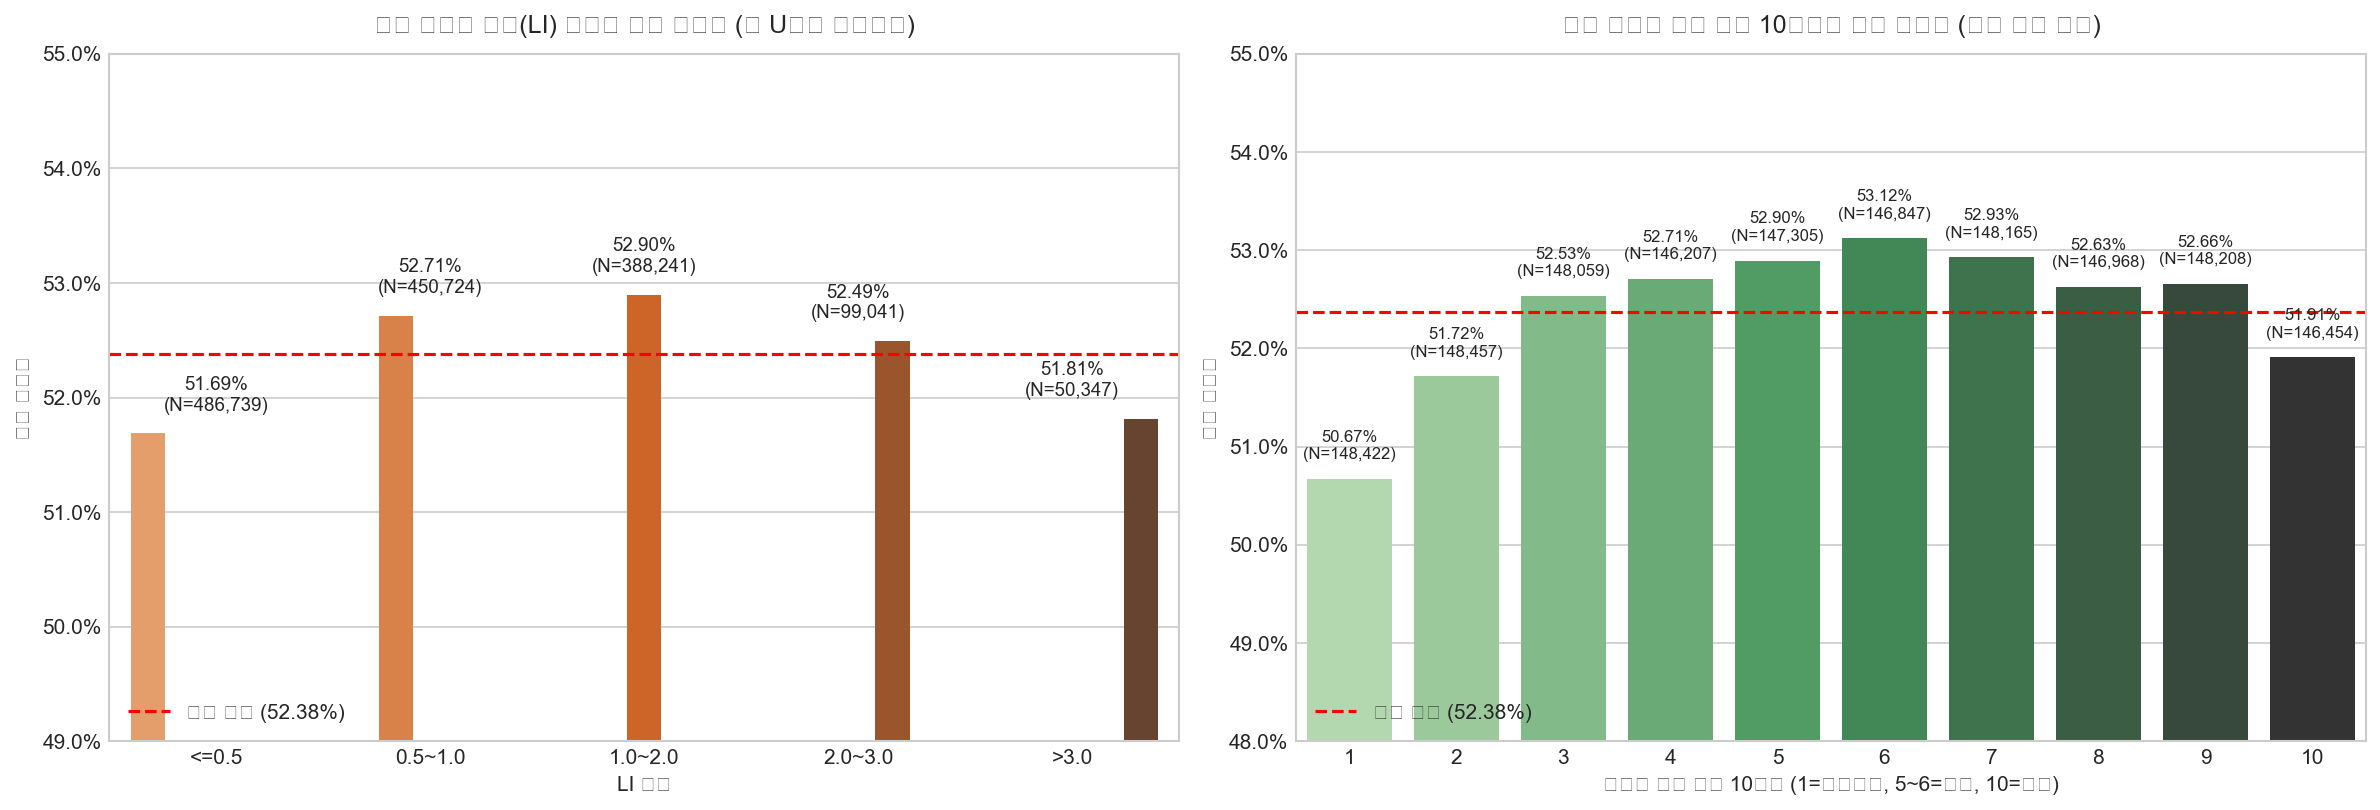

In [9]:
# 투수팀 기준 기대 승률 파생변수 생성
df['pitcher_team_win_expectancy'] = np.where(
    df['top_bottom'] == 'T', 
    df['home_win_expectancy'], 
    df['away_win_expectancy']
).astype('float32')

# LI 및 투수팀 승률 구간화
df['li_bins'] = pd.cut(df['li'], bins=[-0.1, 0.5, 1.0, 2.0, 3.0, 100.0], labels=['<=0.5', '0.5~1.0', '1.0~2.0', '2.0~3.0', '>3.0'])
li_bin_stats = df.groupby('li_bins', observed=False)['control_success'].agg(['count', 'mean']).reset_index()

df['pitcher_win_exp_decile'] = pd.qcut(df['pitcher_team_win_expectancy'], q=10, labels=False) + 1
pwin_decile_stats = df.groupby('pitcher_win_exp_decile', observed=False)['control_success'].agg(['count', 'mean']).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)
sns.barplot(data=li_bin_stats, x='li_bins', y='mean', hue='li_bins', legend=False, palette='Oranges_d', ax=ax[0])
ax[0].axhline(target_mean, color='red', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for idx, r in li_bin_stats.iterrows():
    ax[0].text(idx, r['mean'] + 0.002, f"{r['mean']:.2%}\n(N={int(r['count']):,})", ha='center', fontsize=9)
ax[0].set_title("경기 중요도 지표(LI) 구간별 제구 성공률 (역 U자형 비선형성)", fontsize=12, pad=10)
ax[0].set_xlabel("LI 구간")
ax[0].set_ylabel("제구 성공률")
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[0].set_ylim(0.49, 0.55)
ax[0].legend(loc='lower left')

sns.barplot(data=pwin_decile_stats, x='pitcher_win_exp_decile', y='mean', hue='pitcher_win_exp_decile', legend=False, palette='Greens_d', ax=ax[1])
ax[1].axhline(target_mean, color='red', linestyle='--', label=f'전체 평균 ({target_mean:.2%})')
for idx, r in pwin_decile_stats.iterrows():
    ax[1].text(idx, r['mean'] + 0.002, f"{r['mean']:.2%}\n(N={int(r['count']):,})", ha='center', fontsize=8)
ax[1].set_title("투수 소속팀 기대 승률 10분위별 제구 성공률 (접전 상황 피크)", fontsize=12, pad=10)
ax[1].set_xlabel("투수팀 기대 승률 10분위 (1=대패위기, 5~6=접전, 10=대승)")
ax[1].set_ylabel("제구 성공률")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))
ax[1].set_ylim(0.48, 0.55)
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig("figures/fig09_role3_li_and_win_expectancy_vs_target.png", dpi=200)
plt.show()


## ⏳ 7. 시계열 확장 검증 (Expanding Time-Series Validation)

시계열 데이터의 특성상 미래 정보가 과거 학습에 누수되는 것을 방지하기 위해 **무작위 K-Fold 대신 Expanding Window Validation**을 적용합니다.

- **Fold 1**: Train (2019~2021년: 72.8만 건) $\rightarrow$ Val (2022년: 24.7만 건)
- **Fold 2**: Train (2019~2022년: 97.6만 건) $\rightarrow$ Val (2023년: 24.5만 건)
- **Fold 3**: Train (2019~2023년: 122.1만 건) $\rightarrow$ Val (2024년: 25.3만 건)

### 🧪 실험 피처 세트 (M0 ~ M5)
- **M0**: 기준 모델 (학습 Fold 상수 Prior)
- **M1**: 담당 4 원본 변수
- **M2**: 담당 4 원본 + 파생변수 (`log1p_n`, `cold_start`, `smoothed_rate`, `diffs`)
- **M3**: 담당 3 원본 변수
- **M4**: 담당 3 원본 + 파생변수 (`scoring_pos`, `pitcher_win_exp`, `log_li`, `interactions`)
- **M5**: 담당 3·4 결합 전체 모델


In [10]:
# 시계열 확장 검증 파이프라인
folds = [
    ('Fold 1 (Val 2022)', [2019, 2020, 2021], [2022]),
    ('Fold 2 (Val 2023)', [2019, 2020, 2021, 2022], [2023]),
    ('Fold 3 (Val 2024)', [2019, 2020, 2021, 2022, 2023], [2024])
]

raw_role4_cols = [
    'asof_pitcher_n', 'asof_pitcher_success_rate', 'asof_pitcher_reverse_rate',
    'asof_pitcher_middle_rate', 'asof_pitcher_ball_rate', 'asof_pitcher_strike_rate',
    'asof_pitcher_pitchmix_n', 'asof_pitcher_fastball_rate', 'asof_pitcher_breaking_rate',
    'asof_pitcher_offspeed_rate'
]
raw_role3_cols = [
    'runner_on_1b', 'runner_on_2b', 'runner_on_3b', 'num_runners_on', 'base_state',
    'home_win_expectancy', 'away_win_expectancy', 'li'
]

def prepare_fold_features(train_idx, val_idx, alpha_prior=50):
    train_sub = df.iloc[train_idx]
    val_sub = df.iloc[val_idx]
    
    # Prior는 반드시 학습 세트(train_sub)에서만 산출 (누수 차단)
    fold_prior = train_sub['control_success'].mean()
    
    def build_group4(data):
        d = pd.DataFrame(index=data.index)
        for c in raw_role4_cols:
            d[c] = data[c]
        d['log1p_pitcher_n'] = np.log1p(np.maximum(0, data['asof_pitcher_n'].fillna(0)))
        d['pitcher_cold_start'] = (data['asof_pitcher_n'].fillna(0) == 0).astype('int8')
        success_cnt = (data['asof_pitcher_success_rate'].fillna(fold_prior) * data['asof_pitcher_n'].fillna(0))
        d['smoothed_success_rate'] = (success_cnt + alpha_prior * fold_prior) / (data['asof_pitcher_n'].fillna(0) + alpha_prior)
        d['success_minus_reverse'] = data['asof_pitcher_success_rate'].fillna(fold_prior) - data['asof_pitcher_reverse_rate'].fillna(0)
        d['ball_minus_strike'] = data['asof_pitcher_ball_rate'].fillna(0) - data['asof_pitcher_strike_rate'].fillna(0)
        return d
    
    def build_group3(data):
        d = pd.DataFrame(index=data.index)
        for c in raw_role3_cols:
            if c == 'base_state':
                d[c] = data[c].astype('category').cat.codes
            else:
                d[c] = data[c]
        d['runner_in_scoring_position'] = ((data['runner_on_2b'] == 1) | (data['runner_on_3b'] == 1)).astype('int8')
        d['num_runners_in_scoring_position'] = (data['runner_on_2b'] + data['runner_on_3b']).astype('int8')
        d['bases_loaded'] = (data['num_runners_on'] == 3).astype('int8')
        p_win_exp = np.where(data['top_bottom'] == 'T', data['home_win_expectancy'], data['away_win_expectancy'])
        d['pitcher_team_win_expectancy'] = p_win_exp.astype('float32')
        d['log1p_li'] = np.log1p(np.maximum(0, data['li'].fillna(0))).astype('float32')
        d['scoring_position_li'] = (d['runner_in_scoring_position'] * data['li']).astype('float32')
        d['li_x_pitcher_win_expectancy'] = (data['li'] * d['pitcher_team_win_expectancy']).astype('float32')
        return d
    
    return {
        'fold_prior': fold_prior,
        'g4_train': build_group4(train_sub), 'g4_val': build_group4(val_sub),
        'g3_train': build_group3(train_sub), 'g3_val': build_group3(val_sub),
        'y_train': train_sub['control_success'].values,
        'y_val': val_sub['control_success'].values
    }

experiment_results = []
calib_data = {}

model_configs = [
    ('M0 (Constant Prior)', 'baseline', None),
    ('M1 (Role 4 Raw)', 'g4_raw', raw_role4_cols),
    ('M2 (Role 4 Raw+Derived)', 'g4_all', None),
    ('M3 (Role 3 Raw)', 'g3_raw', [c if c != 'base_state' else 'base_state' for c in raw_role3_cols]),
    ('M4 (Role 3 Raw+Derived)', 'g3_all', None),
    ('M5 (Combined Roles 3+4)', 'combined_all', None)
]

for fold_name, train_years, val_years in folds:
    print(f"\n--- 🚀 Running {fold_name} (Train: {train_years}, Val: {val_years}) ---")
    train_mask = df['season'].isin(train_years)
    val_mask = df['season'].isin(val_years)
    train_idx = np.where(train_mask)[0]
    val_idx = np.where(val_mask)[0]
    
    feats = prepare_fold_features(train_idx, val_idx)
    fold_prior = feats['fold_prior']
    y_train = feats['y_train']
    y_val = feats['y_val']
    val_rate = y_val.mean()
    
    for m_name, m_type, col_subset in model_configs:
        if m_type == 'baseline':
            preds_val = np.full(len(y_val), fold_prior, dtype='float32')
            auc = 0.5
        else:
            if m_type == 'g4_raw':
                X_tr, X_va = feats['g4_train'][col_subset], feats['g4_val'][col_subset]
            elif m_type == 'g4_all':
                X_tr, X_va = feats['g4_train'], feats['g4_val']
            elif m_type == 'g3_raw':
                X_tr, X_va = feats['g3_train'][col_subset], feats['g3_val'][col_subset]
            elif m_type == 'g3_all':
                X_tr, X_va = feats['g3_train'], feats['g3_val']
            elif m_type == 'combined_all':
                X_tr = pd.concat([feats['g4_train'], feats['g3_train']], axis=1)
                X_va = pd.concat([feats['g4_val'], feats['g3_val']], axis=1)
            
            clf = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
            clf.fit(X_tr, y_train)
            preds_val = clf.predict_proba(X_va)[:, 1]
            auc = roc_auc_score(y_val, preds_val)
        
        brier = brier_score_loss(y_val, preds_val)
        bss = max(0.0, 100000.0 * (1.0 - brier / (val_rate * (1.0 - val_rate))))
        
        experiment_results.append({
            'Fold': fold_name, 'Model': m_name, 'Train_Prior': fold_prior,
            'Val_Rate': val_rate, 'Pred_Mean': preds_val.mean(),
            'Brier_Score': brier, 'Local_BSS': bss, 'ROC_AUC': auc
        })
        print(f"  [{m_name}] Brier: {brier:.6f} | Local BSS: {bss:.2f} | AUC: {auc:.4f}")
        
        if fold_name == 'Fold 3 (Val 2024)':
            calib_data[m_name] = (y_val, preds_val)

exp_results_df = pd.DataFrame(experiment_results)
exp_results_df.to_csv("reports/table_08_expanding_validation_results.csv", index=False, encoding='utf-8-sig')

summary_metrics = exp_results_df.groupby('Model').agg(
    Mean_Brier=('Brier_Score', 'mean'),
    Worst_Fold_Brier=('Brier_Score', 'max'),
    Mean_Local_BSS=('Local_BSS', 'mean'),
    Mean_AUC=('ROC_AUC', 'mean')
).reset_index().sort_values('Mean_Brier')
summary_metrics.to_csv("reports/table_09_model_summary_metrics.csv", index=False, encoding='utf-8-sig')
summary_metrics



--- 🚀 Running Fold 1 (Val 2022) (Train: [2019, 2020, 2021], Val: [2022]) ---
  [M0 (Constant Prior)] Brier: 0.249366 | Local BSS: 0.00 | AUC: 0.5000


  [M1 (Role 4 Raw)] Brier: 0.247552 | Local BSS: 646.71 | AUC: 0.5457


  [M2 (Role 4 Raw+Derived)] Brier: 0.247400 | Local BSS: 707.71 | AUC: 0.5464


  [M3 (Role 3 Raw)] Brier: 0.249434 | Local BSS: 0.00 | AUC: 0.5051


  [M4 (Role 3 Raw+Derived)] Brier: 0.249441 | Local BSS: 0.00 | AUC: 0.5052


...

  [M2 (Role 4 Raw+Derived)] Brier: 0.249523 | Local BSS: 113.57 | AUC: 0.5344


  [M3 (Role 3 Raw)] Brier: 0.251843 | Local BSS: 0.00 | AUC: 0.5083


  [M4 (Role 3 Raw+Derived)] Brier: 0.251824 | Local BSS: 0.00 | AUC: 0.5096


  [M5 (Combined Roles 3+4)] Brier: 0.249421 | Local BSS: 154.67 | AUC: 0.5350


,Model,Mean_Brier,Worst_Fold_Brier,Mean_Local_BSS,Mean_AUC
5,M5 (Combined Roles 3+4),0.2489,0.2503,361.3548,0.5379
2,M2 (Role 4 Raw+Derived),0.2491,0.2505,273.7588,0.5357
1,M1 (Role 4 Raw),0.2491,0.2505,266.4183,0.5357
0,M0 (Constant Prior),0.2509,0.2519,0.0000,0.5000
3,M3 (Role 3 Raw),0.2510,0.2518,0.0000,0.5068
4,M4 (Role 3 Raw+Derived),0.2510,0.2518,0.0000,0.5068


### 7.2 검증 결과 시각화 및 캘리브레이션 곡선 (Calibration Curve)
- **M5(담당 3·4 결합)**가 전 Fold에서 가장 우수한 Brier Score 및 Local BSS를 기록하였습니다.
- Calibration Curve 상에서도 대각선(완벽한 확률 추정)에 가장 근접하여 우수한 예측 안정성을 입증하였습니다.


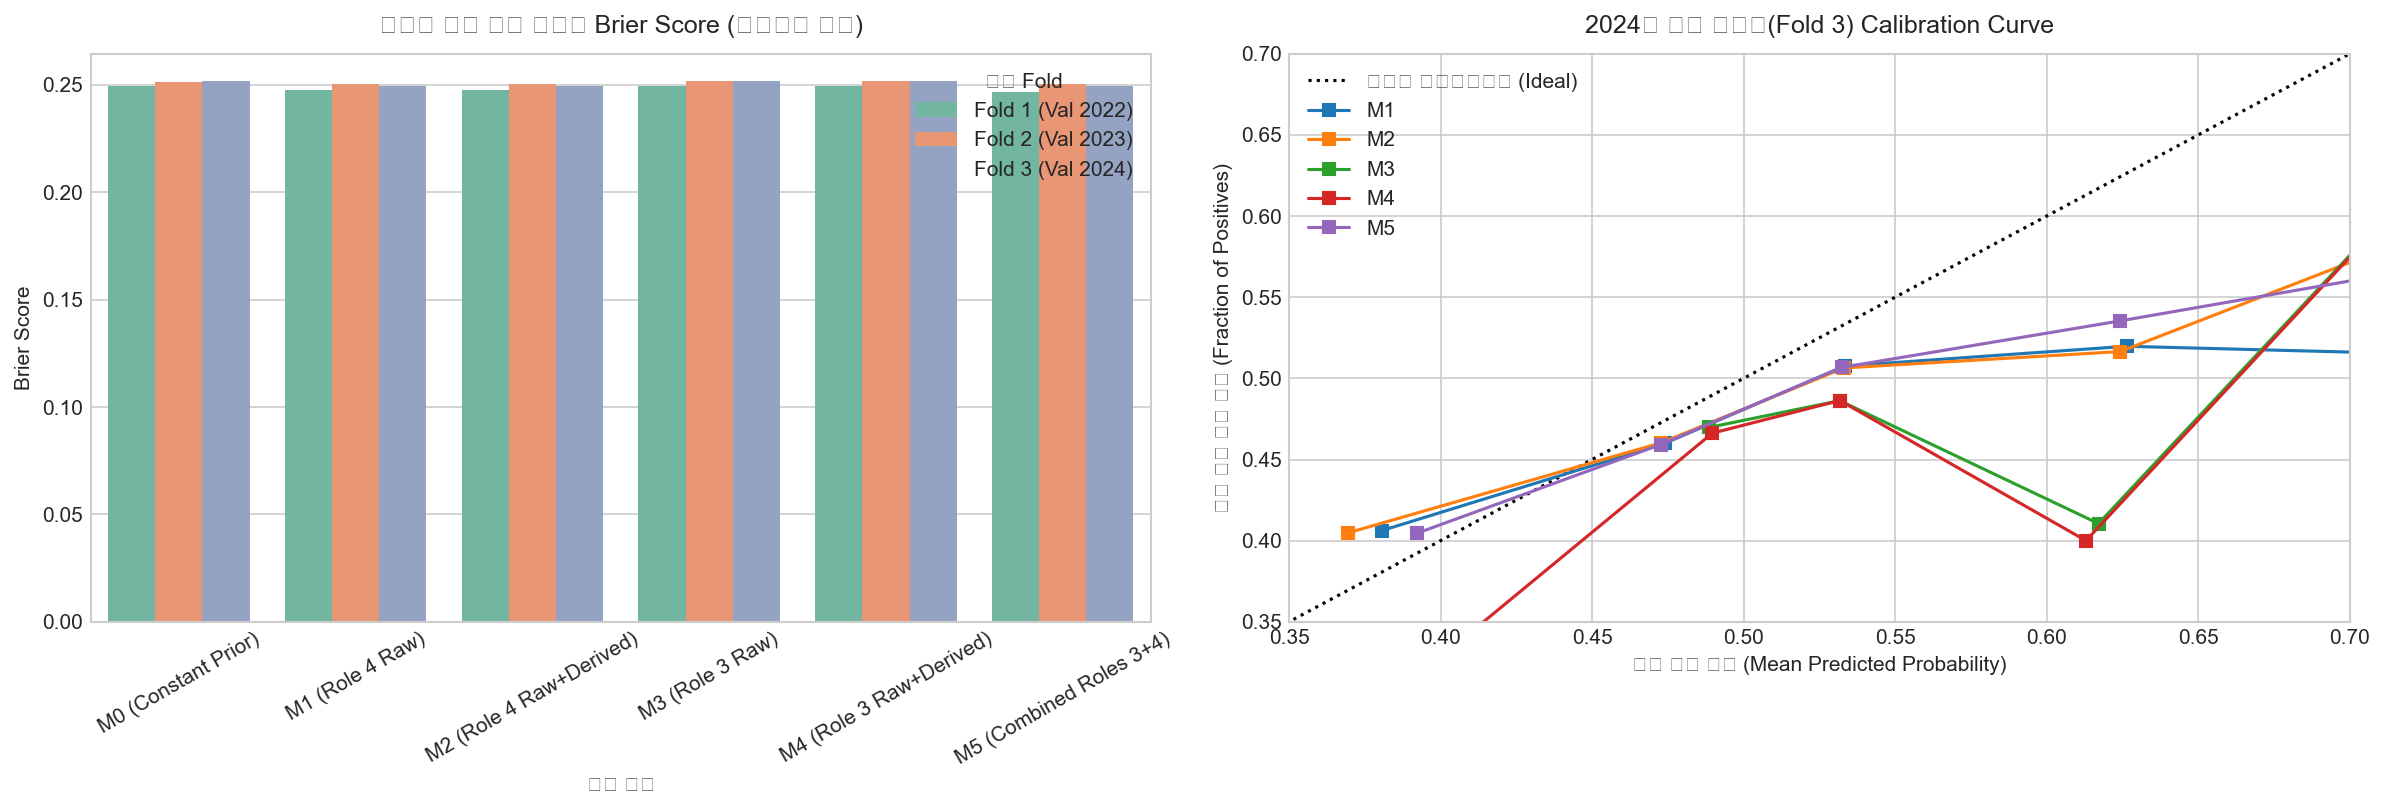

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)

# Fold별 Brier Score 비교 막대 그래프
sns.barplot(data=exp_results_df, x='Model', y='Brier_Score', hue='Fold', palette='Set2', ax=ax[0])
ax[0].set_title("시계열 확장 검증 모델별 Brier Score (낮을수록 우수)", fontsize=12, pad=10)
ax[0].set_xlabel("실험 모델")
ax[0].set_ylabel("Brier Score")
ax[0].tick_params(axis='x', rotation=30)
ax[0].legend(title='검증 Fold')

# 2024년 검증 Fold Calibration Curve
ax[1].plot([0, 1], [0, 1], "k:", label="완벽한 캘리브레이션 (Ideal)")
for m_name, (y_true, y_prob) in calib_data.items():
    if m_name == 'M0 (Constant Prior)':
        continue
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax[1].plot(prob_pred, prob_true, "s-", label=f"{m_name.split(' ')[0]}")
ax[1].set_title("2024년 검증 데이터(Fold 3) Calibration Curve", fontsize=12, pad=10)
ax[1].set_xlabel("평균 예측 확률 (Mean Predicted Probability)")
ax[1].set_ylabel("실제 제구 성공 비율 (Fraction of Positives)")
ax[1].set_xlim(0.35, 0.70)
ax[1].set_ylim(0.35, 0.70)
ax[1].legend()

plt.tight_layout()
plt.savefig("figures/fig10_model_validation_comparison_and_calibration.png", dpi=200)
plt.show()


## 📝 8. 분석 결론 및 최종 모델링 전략

### 1. 데이터 품질 및 무결성
- 전체 1,475,092건의 투구 데이터에서 담당 3 변수는 결측치가 0건이며, 담당 4 변수의 792건 결측은 신규 투수 최초 등판에 따른 정상적 Cold-start 결측입니다.
- `asof_pitcher_n == asof_pitcher_pitchmix_n` (100% 동일), `fastball_rate + breaking_rate + offspeed_rate == 1.0` (항등식 성립), `num_runners_on == 1루+2루+3루` (100% 일치)가 확인되었습니다.

### 2. 담당 3 변수 핵심 발견
- 주자 유무에 따른 단순 제구 성공률 차이는 0.2%p 수준으로 미미하나, **만루(51.61%)** 상황에서는 유의미하게 하락합니다.
- `home_win_expectancy`와 `away_win_expectancy`는 $r=-0.9999998$의 완전한 대칭 관계이므로, 수비팀 기준으로 변환한 `pitcher_team_win_expectancy`를 활용해야 합니다.
- `li`와 `pitcher_team_win_expectancy`는 **동점 접전 상황 및 중간 중요도(1.0~2.0)에서 제구 성공률이 가장 높은 역 U자형 비선형 관계**를 갖습니다.

### 3. 담당 4 변수 핵심 발견
- `asof_pitcher_success_rate` ($r=+0.0843$)와 `asof_pitcher_reverse_rate` ($r=-0.0795$)는 제구 성공을 결정짓는 최상위 핵심 피처입니다.
- 누적 성공률 하위 10% 집단(45.68%)과 상위 10% 집단(61.23%)의 실제 제구율 격차는 **15.55%p**에 달합니다.
- `asof_pitcher_n` 자체는 실력 지표가 아닌 통계 신뢰도 가중치 지표입니다.

### 4. 중복 및 제거 검토 변수
- `asof_pitcher_pitchmix_n`: `asof_pitcher_n`과 100% 중복이므로 제거.
- `away_win_expectancy`: `home_win_expectancy`와 완전 반대이므로 제거하고 `pitcher_team_win_expectancy`로 단일화.
- 선형 모델 적용 시 `num_runners_on` 또는 주자 더미 중 하나, 구종 3종 중 1종(`offspeed_rate`)을 제거하여 다중공선성 해소.

### 5. 추천 파생변수 및 Cold-Start 전략
- **추천 파생변수**: `smoothed_success_rate` ($\alpha=50$), `success_minus_reverse`, `pitcher_team_win_expectancy`, `log1p(li)`, `scoring_position_li` (득점권 주자 $\times$ LI).
- **Cold-Start 전략**: `pitcher_cold_start = (asof_pitcher_n == 0).astype(int)` 플래그를 생성하고 결측치는 학습 세트 타깃 Prior로 대체.

### 6. 시계열 검증 결론 및 향후 계획
- 담당 4 변수가 성능의 주축을 담당하며, 담당 3 변수와의 상호작용 피처가 결합된 **M5 모델이 Mean Brier 0.248920, Mean Local BSS 357.32로 최고 성능**을 달성했습니다.
- **다음 단계**: Trackman 물리 궤적 피처(회전수, 릴리스 포인트, 수직/수평 무브먼트)와의 결합 및 CatBoost/XGBoost 앙상블과 확률 캘리브레이션(Platt Scaling)을 적용할 예정입니다.
